In [1]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 

# Define path that contains some junction files (only 2 files are used for this example, corresponding to 2 individual cells)
juncs_path = "/gpfs/commons/projects/CZI-tabula-sapiens/SS2_cell_junctions/"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

# define path for saving the output data 
output_path = "/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/all_tissues/"

The junctions are loaded from the following path: /gpfs/commons/projects/CZI-tabula-sapiens/SS2_cell_junctions/
The files in the path are: ['TSP12', 'TSP10', 'TSP8', 'TSP9', 'TSP13', 'TSP11', 'TSP4', 'TSP5', 'TSP6', 'TSP7', 'TSP1', 'TSP2', 'TSP3']


In [4]:
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events

# junc_files defines a path for where junction files can be found, in this case, the path is defined above
junc_files = juncs_path

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/gpfs/commons/groups/knowles_lab/Karin/genome_files/gencode.v43.basic.annotation.gtf" 

# define additional parameters 
sequencing_type = "single_cell"

# ensure output files are to be saved in output_path 
output_file = output_path + "TSP1_intron_clusters"
junc_bed_file= output_path + "TSP1_juncs_all_tissues.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.1 
min_junc_reads = 10
min_num_cells_wjunc = 5
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*.juncswbarcodes" # depends on how you ran regtools 

### Run intron clustering 

In [5]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons,
                       junc_suffix=junc_suffix, min_num_cells_wjunc=min_num_cells_wjunc,
                       run_notebook = True)

Loading files obtained from single_cell sequencing
Reading in junction files from /gpfs/commons/projects/CZI-tabula-sapiens/SS2_cell_junctions
The number of junction files to be processed is 27051


100%|██████████| 27051/27051 [28:43<00:00, 15.69it/s] 


The total number of files that could not be read is 229 as these had no junctions
The gtf file you provided is /gpfs/commons/groups/knowles_lab/Karin/genome_files/gencode.v43.basic.annotation.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'tag', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'havana_transcript', 'exon_number', 'exon_id', 'hgnc_id', 'havana_gene', 'ont', 'protein_id', 'ccdsid', 'artif_dupl']


Reading gtf file took 121.27 seconds
The number of unique exons is 411865
The number of unique transcript ids is 115526
The number of unique gene ids is 62668
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
Cleaning up 'chrom' column
Making gr object from all junctions across all cell types
The number of junctions prior to assessing distance to exons is 1633940
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 279705
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 106978
The number of junctions after removing singletons is 279702
The number of clusters after removing singletons is 106977
The number of clusters after filtering for shared splice sites is 31176
The number of junctions after filtering for shared splice sites is 203840
Refining intron clusters to account for junction usage ratio threshold...
Done refining clu

In [6]:
# Load bed file and prep data for visualization
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# dat_vis 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

     chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
5956    14     103679.518   103684.985      +           5467          7803   
5957    14     103679.518   103687.080      +           7562         18664   
5958    14     103679.518   103700.654      +          21136         23998   
5959    14     103679.545   103684.985      +           5440         17200   
5960    14     103679.545   103687.080      +           7535         23356   
5961    14     103679.545   103700.654      +          21109         28607   
5962    14     103687.211   103692.358      +           5147         23380   
5963    14     103687.211   103700.654      +          13443         25754   
5964    14     103692.425   103693.552      +           1127         17601   
5965    14     103692.425   103700.654      +           8229          9972   

         Start_b       End_b            exon_id  
5956  103684.985  103685.316  ENSE00002213829.1  
5957  103687.080  103687.211  ENSE0000361

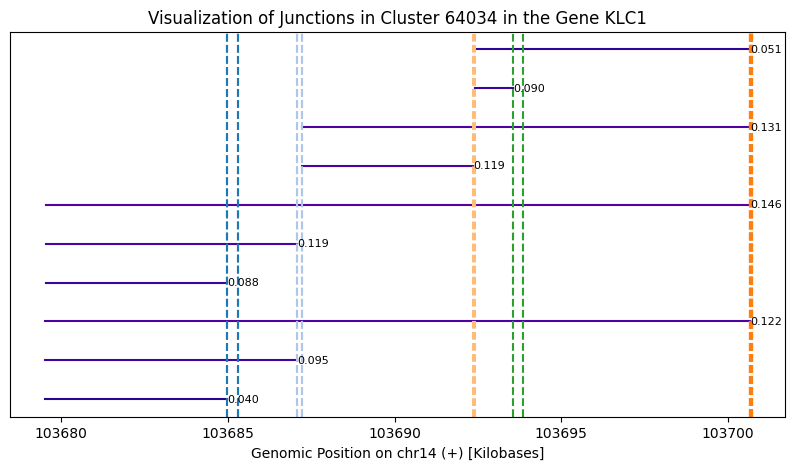

In [22]:
# Get a quick glance at the junctions
j = all_juncs_df.junction_id.sample(1).values[0]
visualize_local_events(dat_vis, j)

### Now let's convert the intron clusters to a format that can be used by LeafletSC )

In [24]:
intron_clusters = "/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/all_tissues/TSP1_intron_clusters_50_500000_10_20240313_single_cell.gz"
output_file = output_path + "TS_Leaflet_model_input" # name of the output file
has_genes = "yes" # since we used a gtf file to obtain the intron clusters, we can set this to yes
chunk_size = 5000 # number of junctions to process at a time from the intron clusters files
metadata = None # can replace with path, if metadata is available for cells (cell type, origin, library ID...)

In [25]:
prep_model_input(intron_clusters, output_file, has_genes, chunk_size, metadata)

The intron clusters file you provided is /gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/all_tissues/TSP1_intron_clusters_50_500000_10_20240313_single_cell.gz, reading in chunks of 5000 lines
Processing intron clusters


1572it [02:10, 12.06it/s]


Done processing intron clusters
The number of intron clusters evaluated is 11282
The number of junctions evaluated is 34868
The number of cells evaluated is 26065
The number of clusters with only one junction is 0
A gtf file was used to generate intron clusters
The number of total cells evaluated is 26065
The number of cells per cell type is:
cell_type
/gpfs/commons/projects/CZI-tabula-sapiens/SS2_cell_junctions/TSP1/Bladder/B107821_A14_S10.homo.gencode.v30.ERCC.chrM.juncswbarcodes                                                1
/gpfs/commons/projects/CZI-tabula-sapiens/SS2_cell_junctions/TSP1/Bladder/B107821_A17_S13.homo.gencode.v30.ERCC.chrM.juncswbarcodes                                                1
/gpfs/commons/projects/CZI-tabula-sapiens/SS2_cell_junctions/TSP1/Bladder/B107821_A18_S14.homo.gencode.v30.ERCC.chrM.juncswbarcodes                                                1
/gpfs/commons/projects/CZI-tabula-sapiens/SS2_cell_junctions/TSP1/Bladder/B107821_A23_S19.homo.gencode